# DiffusionNet Autoencoder: Shape Clustering

This notebook loads the latent embeddings from the trained DiffusionNet autoencoder
and reproduces the tSNE/clustering analysis from `multi_shape_clustering.ipynb`
for direct comparison with the spectral (bag-of-features HKS) baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import json
import os

In [ ]:
# Configuration
data_path = '../../../Data/small_meshes'
output_dir = 'outputs/latent_16_width_32'

In [ ]:
# Load DiffusionNet latent embeddings
res = np.load(os.path.join(output_dir, 'latent_embeddings.npz'), allow_pickle=True)
latents = res['latents']
ids = res['ids']
timepoints = res['timepoints']

print(f'Latent shape: {latents.shape}')
print(f'Number of organoids: {len(ids)}')

In [98]:
# Optionally load the spectral baseline for comparison
try:
    res_baseline = np.load(f'{data_path}/multi_shape_bof_results_raw_value.npz', allow_pickle=True)
    baseline_ids = res_baseline['filtered_ids']
    baseline_spectrums = res_baseline['filtered_spectrums']
    baseline_times = res_baseline['filtered_time']
    baseline_areas = res_baseline['filtered_areas']
    has_baseline = True
    print(f'Baseline loaded: {len(baseline_ids)} organoids')
except FileNotFoundError:
    has_baseline = False
    print('No baseline found (multi_shape_bof_results_raw_value.npz)')

Baseline loaded: 125 organoids


## tSNE of DiffusionNet Latent Space

In [99]:
# Standardize latents before tSNE
scaler = StandardScaler()
latents_scaled = np.copy(latents) #scaler.fit_transform(latents)

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_coords = tsne.fit_transform(latents_scaled)
print('tSNE done.')

tSNE done.


In [100]:
# KMeans clustering
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_id = kmeans.fit_predict(latents_scaled)

# Find cluster centers in tSNE space
nn = NearestNeighbors(n_neighbors=5).fit(latents_scaled)
distances, indices = nn.kneighbors(kmeans.cluster_centers_)
weights = 1 / (distances + 1e-8)
weights /= weights.sum(axis=1, keepdims=True)
cluster_pcs = np.sum(weights[:, :, None] * tsne_coords[indices], axis=1)

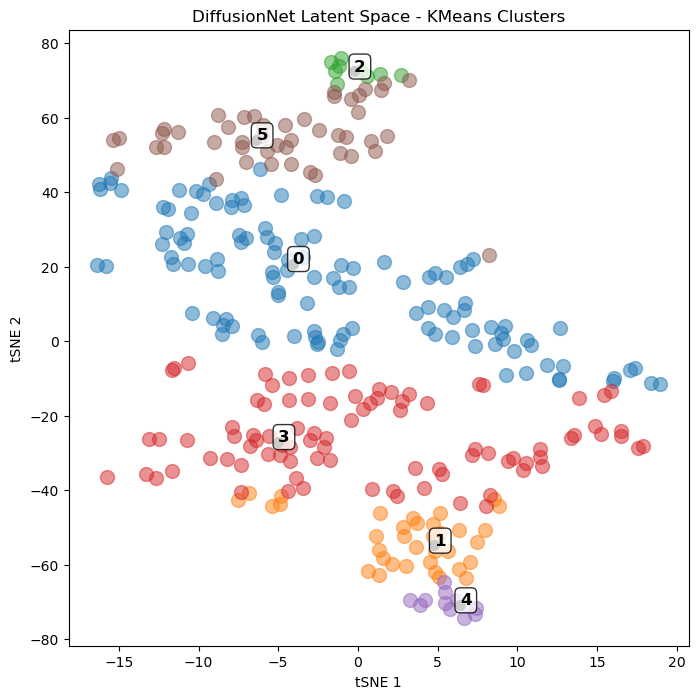

In [101]:
# Plot: clusters
plt.figure(figsize=(8, 8))

for cid in range(n_clusters):
    mask = cluster_id == cid
    plt.plot(tsne_coords[mask, 0], tsne_coords[mask, 1], 'o', alpha=0.5, markersize=10)

plt.plot(cluster_pcs[:, 0], cluster_pcs[:, 1], 'o', markersize=7, color='black')
for i in range(len(cluster_pcs)):
    plt.text(cluster_pcs[i, 0], cluster_pcs[i, 1],
             str(i), fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))

plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')
plt.title('DiffusionNet Latent Space - KMeans Clusters')
plt.show()

Cluster 0: closest organoid ID = ['day4p5_B05_97' 'day4p5_B03_68' 'day4p5_B05_45' 'day4p5_B05_29'], dist = [4.3503832e-08 4.4365084e-08 6.1914129e-08 6.6607882e-08]
Cluster 1: closest organoid ID = ['day4p5_B03_56' 'day4p5_B05_30' 'day4p5_B03_92' 'day4p5_B04_62'], dist = [7.9356829e-07 1.5794925e-06 3.8736666e-06 3.9240203e-06]
Cluster 2: closest organoid ID = ['day4p5_B03_144' 'day4p5_B05_87' 'day4p5_B05_54' 'day4p5_B05_95'], dist = [5.0972113e-07 6.8231606e-07 1.2360125e-06 1.2948951e-06]
Cluster 3: closest organoid ID = ['day4p5_B02_43' 'day4p5_B02_132' 'day4p5_B02_94' 'day4p5_B03_95'], dist = [1.1375320e-07 1.2956455e-07 3.6966767e-07 3.7085945e-07]
Cluster 4: closest organoid ID = ['day4p5_B02_42' 'day4p5_B04_66' 'day4p5_B03_166' 'day4p5_B02_126'], dist = [3.8920655e-07 6.2879673e-07 6.7534057e-07 7.2100084e-07]
Cluster 5: closest organoid ID = ['day4p5_B03_158' 'day4p5_B03_163' 'day4p5_B03_41' 'day4p5_B02_85'], dist = [2.7542006e-08 1.4464088e-07 1.8504413e-07 1.8630642e-07]


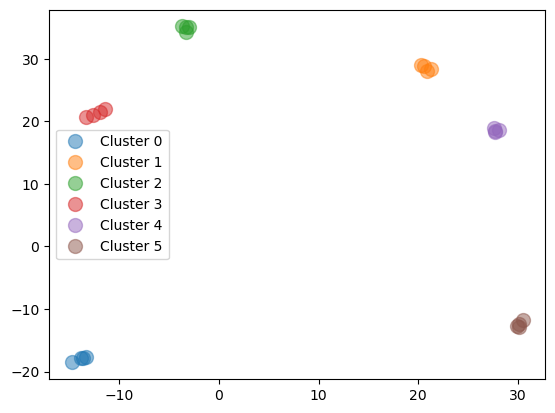

In [93]:
for cid in range(n_clusters):
    center = kmeans.cluster_centers_[cid]

    # find four cloest points to the cluster center in the original latent space
    min_dist_idx = np.argsort(np.linalg.norm(latents_scaled - center, axis=1))[:4]

    print(f'Cluster {cid}: closest organoid ID = {ids[min_dist_idx]}, dist = {np.linalg.norm(latents_scaled[min_dist_idx] - center, axis=1)}')

    plt.plot(tsne_coords[min_dist_idx, 0], tsne_coords[min_dist_idx, 1], 'o', alpha=0.5, markersize=10, label=f'Cluster {cid}')
plt.legend() 
plt.show() 
    

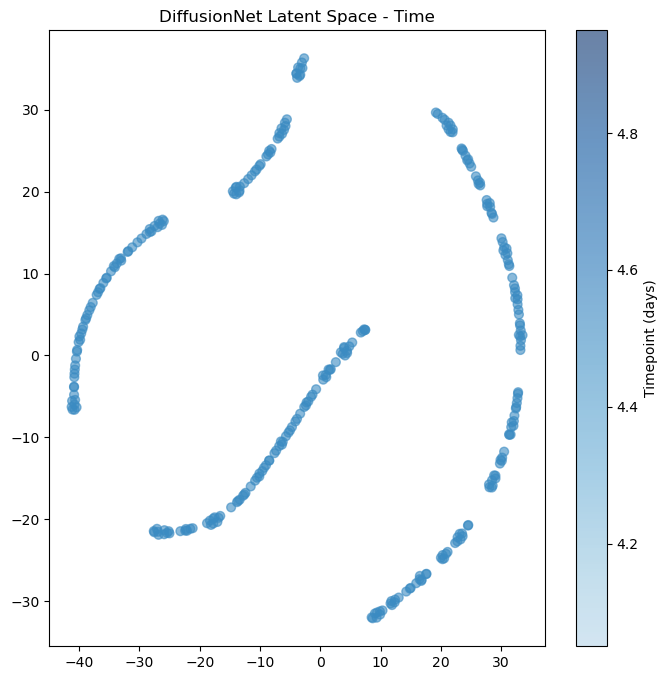

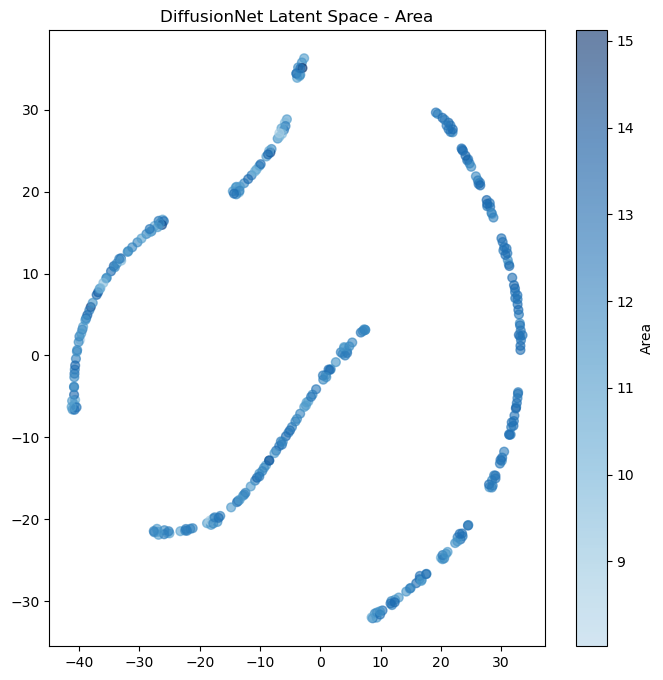

In [94]:
# Plot: coloured by time
cmap = plt.get_cmap('Blues')
colors = cmap(np.linspace(0.3, 1.0, 256))
custom_cmap = ListedColormap(colors)

times_array = np.array([times_dic.get(t, 0) for t in times])

plt.figure(figsize=(8, 8))
sc = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                 c=times_array, s=40, alpha=0.6, cmap=custom_cmap)
plt.colorbar(sc, label='Timepoint (days)')
plt.title('DiffusionNet Latent Space - Time')
plt.show()

plt.figure(figsize=(8, 8))
sc = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                 c=areas, s=40, alpha=0.6, cmap=custom_cmap)
plt.colorbar(sc, label='Area')
plt.title('DiffusionNet Latent Space - Area')
plt.show()

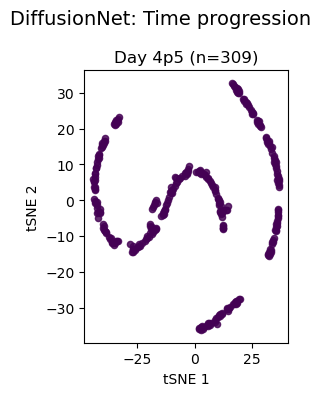

In [84]:
# Plot: per-timepoint panels
unique_times = np.unique(times)
cmap_time = plt.cm.viridis
colors_time = [cmap_time(i / max(1, len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(1, len(unique_times), figsize=(3 * len(unique_times), 4))
if len(unique_times) == 1:
    axes = [axes]

for i, t in enumerate(unique_times):
    ax = axes[i]
    ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c='lightgray', alpha=0.5, s=10)
    mask = times == t
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               c=[colors_time[i]], alpha=0.8, s=20)
    ax.set_title(f'Day {t} (n={mask.sum()})')
    ax.set_xlabel('tSNE 1')

axes[0].set_ylabel('tSNE 2')
plt.suptitle('DiffusionNet: Time progression', fontsize=14)
plt.tight_layout()
plt.show()

In [85]:
# Save results
df = pd.DataFrame({
    'label_uid': ids,
    'tsne1': tsne_coords[:, 0],
    'tsne2': tsne_coords[:, 1],
    'cluster': cluster_id,
})
df.to_csv(os.path.join(data_path, 'diffusionnet_tsne_results.csv'), index=False)
print(df.head())

       label_uid      tsne1      tsne2  cluster
0  day4p5_B02_96  31.463219  16.215879        4
1  day4p5_B02_41 -33.205982 -11.527939        0
2   day4p5_B02_7   6.431442 -34.748848        5
3  day4p5_B02_68 -36.457146 -10.685793        0
4   day4p5_B02_6 -43.418415   3.708497        3


In [41]:
print(output_dir)

outputs


## Comparison with Spectral Baseline

If the spectral baseline results exist, show both embeddings side by side.

Common organoids: 125 / DN: 309 / Baseline: 125
Baseline tSNE loaded from CSV


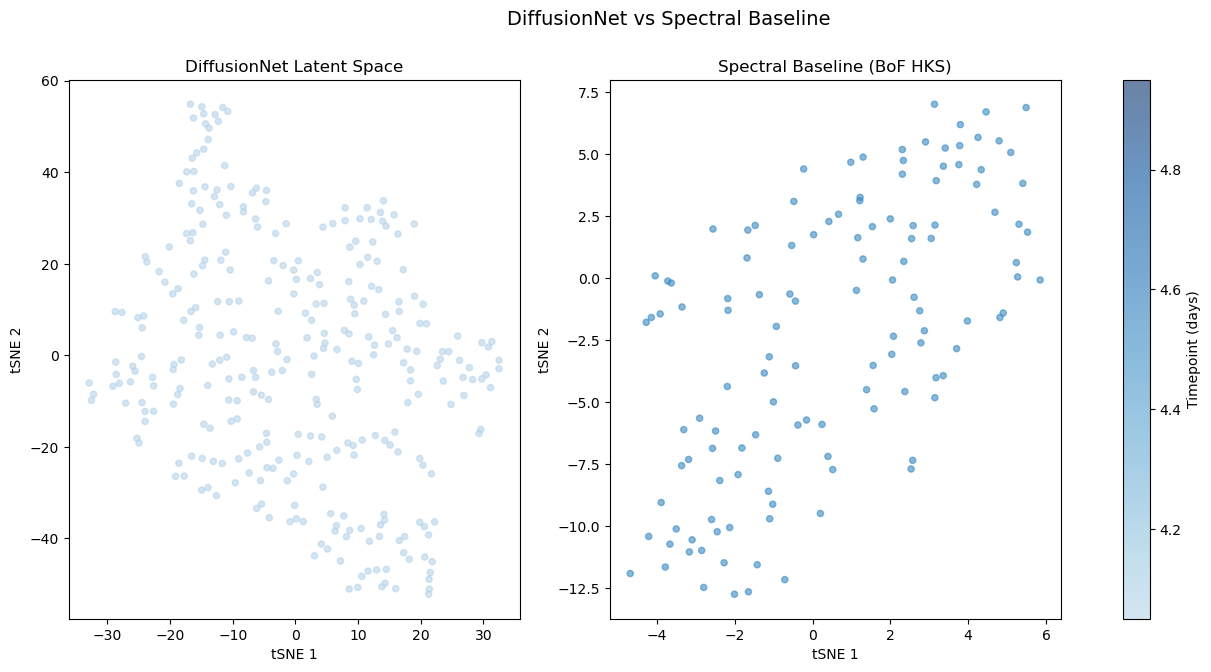

In [26]:
if has_baseline:
    # Match IDs between the two methods
    dn_id_set = set(ids)
    bl_id_set = set(baseline_ids)
    common_ids = sorted(dn_id_set & bl_id_set)
    print(f'Common organoids: {len(common_ids)} / DN: {len(ids)} / Baseline: {len(baseline_ids)}')

    # Load baseline tSNE if it exists
    try:
        bl_tsne = pd.read_csv(f'{data_path}/tsne_results_raw_value.csv')
        print('Baseline tSNE loaded from CSV')
    except FileNotFoundError:
        print('No baseline tSNE CSV found')
        bl_tsne = None

    if bl_tsne is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        ax1.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                    c=times_array, s=20, alpha=0.6, cmap=custom_cmap)
        ax1.set_title('DiffusionNet Latent Space')
        ax1.set_xlabel('tSNE 1')
        ax1.set_ylabel('tSNE 2')

        bl_times_array = np.array([times_dic.get(t, 0) for t in bl_tsne['label_uid'].apply(
            lambda x: x.split('_')[0][3:])])
        sc = ax2.scatter(bl_tsne['tsne1'], bl_tsne['tsne2'],
                         c=bl_times_array, s=20, alpha=0.6, cmap=custom_cmap)
        ax2.set_title('Spectral Baseline (BoF HKS)')
        ax2.set_xlabel('tSNE 1')
        ax2.set_ylabel('tSNE 2')

        plt.colorbar(sc, ax=[ax1, ax2], label='Timepoint (days)')
        plt.suptitle('DiffusionNet vs Spectral Baseline', fontsize=14)
        plt.show()
else:
    print('No baseline data to compare.')

## Reconstructed Shape Inspection

Load the trained model and visualise original vs reconstructed meshes
for selected organoids.

In [2]:
import sys, torch
sys.path.insert(0, os.path.join(os.getcwd()))
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', '..'))

from model import OrganoidAutoencoder
from dataset import OrganoidDataset
from diffusion_net.utils import generate_icosphere

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [ ]:
# --- Configuration: adjust these to match your training run ---
model_path = os.path.join(output_dir, 'model_final.pt')
sphere_template_path = os.path.join(output_dir, 'sphere_template.pt')

# Model hyperparameters — must match what was used during training
C_latent = 16
C_width = 32
C_fate = 0

# Dataset settings
k_eig = 128
op_cache_dir = '../../op_cache'

In [ ]:
# Load sphere template
sphere_data = torch.load(sphere_template_path, map_location=device, weights_only=True)
sphere_verts = sphere_data['verts'].to(device)
sphere_faces = sphere_data['faces']
print(f'Sphere template: {sphere_verts.shape[0]} verts, {sphere_faces.shape[0]} faces')

# Load dataset
dataset = OrganoidDataset(
    data_path=data_path,
    k_eig=k_eig,
    op_cache_dir=op_cache_dir,
)

# Load model
n_hks = dataset.n_hks
model = OrganoidAutoencoder(
    C_in=n_hks, C_latent=C_latent, C_fate=C_fate, C_width=C_width
).to(device)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()
print(f'Model loaded from {model_path}')

In [ ]:
@torch.no_grad()
def reconstruct(model, dataset, idx, sphere_verts, device):
    """Run one sample through the model and return original + reconstructed vertices."""
    sample = dataset[idx]

    hks = sample['hks'].to(device)
    verts = sample['verts'].to(device)
    mass = sample['mass'].to(device)
    L = sample['L'].to(device)
    evals = sample['evals'].to(device)
    evecs = sample['evecs'].to(device)
    gradX = sample['gradX'].to(device)
    gradY = sample['gradY'].to(device)

    p_recon, z = model(hks, verts, sphere_verts, mass, L, evals, evecs, gradX, gradY)

    return {
        'verts_orig': verts.cpu().numpy(),
        'faces_orig': sample['faces'].numpy(),
        'verts_recon': p_recon.squeeze(0).cpu().numpy(),
        'faces_recon': sphere_faces.cpu().numpy(),
        'z': z.squeeze(0).cpu().numpy(),
        'id': sample['meta']['id'],
    }

In [ ]:
def plot_mesh_comparison(result, elev=25, azim=45):
    """Plot original and reconstructed mesh side by side."""
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection

    fig = plt.figure(figsize=(14, 6))

    for i, (key_v, key_f, title) in enumerate([
        ('verts_orig', 'faces_orig', 'Original'),
        ('verts_recon', 'faces_recon', 'Reconstructed'),
    ]):
        ax = fig.add_subplot(1, 2, i + 1, projection='3d')
        v = result[key_v]
        f = result[key_f]

        # Build polygon collection for the mesh faces
        triangles = v[f]
        poly = Poly3DCollection(triangles, alpha=0.6, edgecolor='k', linewidth=0.1)
        poly.set_facecolor('steelblue')
        ax.add_collection3d(poly)

        # Set axis limits from the data
        margin = 0.1
        for dim, label in enumerate(['X', 'Y', 'Z']):
            lo, hi = v[:, dim].min(), v[:, dim].max()
            pad = (hi - lo) * margin
            getattr(ax, f'set_{label.lower()}lim')(lo - pad, hi + pad)
            getattr(ax, f'set_{label.lower()}label')(label)

        ax.set_title(f'{title}\n({v.shape[0]} verts, {f.shape[0]} faces)')
        ax.view_init(elev=elev, azim=azim)

    fig.suptitle(f'Organoid: {result["id"]}  (scale={result["scale_factor"]:.2f})',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
# Reconstruct and visualise a few samples
# Pick indices spread across the dataset to see variety
sample_indices = np.linspace(0, len(dataset) - 1, 6, dtype=int)

for idx in sample_indices:
    result = reconstruct(model, dataset, idx, sphere_verts, device)
    plot_mesh_comparison(result)

### Inspect cluster representatives

Reconstruct the organoids closest to each KMeans cluster centre.

In [ ]:
# Build a mapping from organoid ID to dataset index
id_to_dataset_idx = {dataset.entries[i]['id']: i for i in range(len(dataset))}

for cid in range(n_clusters):
    center = kmeans.cluster_centers_[cid]
    closest_idx_in_latents = np.argmin(np.linalg.norm(latents_scaled - center, axis=1))
    org_id = ids[closest_idx_in_latents]

    if org_id not in id_to_dataset_idx:
        print(f'Cluster {cid}: {org_id} not found in current dataset, skipping')
        continue

    dataset_idx = id_to_dataset_idx[org_id]
    print(f'\n--- Cluster {cid} representative: {org_id} ---')
    result = reconstruct(model, dataset, dataset_idx, sphere_verts, device)
    plot_mesh_comparison(result)

### Inspect a specific organoid by ID

Change `target_id` below to inspect any organoid.

In [ ]:
# --- Change this to any organoid ID you want to inspect ---
target_id = ids[0]  # or e.g. 'day4p5_B02_96'

if target_id in id_to_dataset_idx:
    dataset_idx = id_to_dataset_idx[target_id]
    result = reconstruct(model, dataset, dataset_idx, sphere_verts, device)
    plot_mesh_comparison(result)

    # Also show from multiple viewing angles
    for azim in [0, 90, 180, 270]:
        plot_mesh_comparison(result, elev=25, azim=azim)
else:
    print(f'{target_id} not found in dataset. Available IDs:')
    print(list(id_to_dataset_idx.keys())[:10], '...')

### Chamfer distance distribution across the dataset

In [ ]:
from diffusion_net.utils import chamfer_distance

# Compute Chamfer distance for every sample
chamfer_dists = []
recon_ids = []

for idx in range(len(dataset)):
    result = reconstruct(model, dataset, idx, sphere_verts, device)
    cd = chamfer_distance(
        torch.tensor(result['verts_recon']),
        torch.tensor(result['verts_orig'])
    ).item()
    chamfer_dists.append(cd)
    recon_ids.append(result['id'])

chamfer_dists = np.array(chamfer_dists)
print(f'Chamfer distance: mean={chamfer_dists.mean():.6f}, '
      f'median={np.median(chamfer_dists):.6f}, '
      f'max={chamfer_dists.max():.6f}')

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(chamfer_dists, bins=40, edgecolor='k', alpha=0.7)
ax.axvline(np.median(chamfer_dists), color='r', linestyle='--', label=f'median={np.median(chamfer_dists):.4f}')
ax.set_xlabel('Chamfer Distance')
ax.set_ylabel('Count')
ax.set_title('Reconstruction quality across dataset')
ax.legend()
plt.tight_layout()
plt.show()

# Show the worst reconstructions
worst_indices = np.argsort(chamfer_dists)[-3:]
print('\nWorst reconstructions:')
for idx in worst_indices:
    dataset_idx = id_to_dataset_idx.get(recon_ids[idx], idx)
    print(f'  {recon_ids[idx]}: CD={chamfer_dists[idx]:.6f}')
    result = reconstruct(model, dataset, dataset_idx, sphere_verts, device)
    plot_mesh_comparison(result)

### Colour tSNE by reconstruction quality

In [ ]:
# Map Chamfer distances back to the latent embedding ordering
cd_by_id = dict(zip(recon_ids, chamfer_dists))
cd_for_tsne = np.array([cd_by_id.get(oid, np.nan) for oid in ids])

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                c=cd_for_tsne, s=40, alpha=0.7, cmap='RdYlGn_r')
plt.colorbar(sc, label='Chamfer Distance')
ax.set_xlabel('tSNE 1')
ax.set_ylabel('tSNE 2')
ax.set_title('Latent space coloured by reconstruction error')
plt.tight_layout()
plt.show()